<a href="https://colab.research.google.com/github/bhanuprakash227/DataScience---Exelr/blob/main/10_08_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('insurance.csv')
df.head()

,age,gender,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.shape

(1338, 7)

In [4]:
df.size

9366

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   gender    1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.isnull().sum()

,0
age,0
gender,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [7]:
df.duplicated().sum()

np.int64(1)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df.duplicated().sum()

np.int64(0)

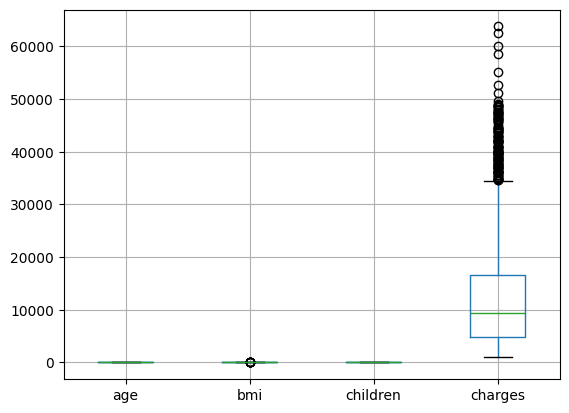

In [10]:
df.boxplot()
plt.show()

In [11]:
#Outlier Capping
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    IQR=q3-q1
    lower=q1-1.5*IQR
    upper=q3+1.5*IQR
    df[i]=df[i].clip(lower,upper)

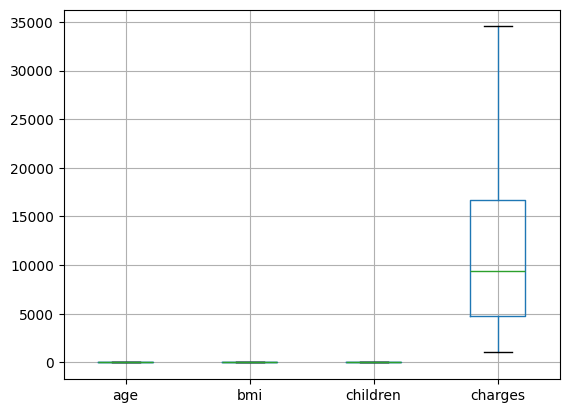

In [12]:
df.boxplot()
plt.show()

In [13]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['gender']=le.fit_transform(df['gender'])
df['region']=le.fit_transform(df['region'])
df['smoker']=le.fit_transform(df['smoker'])

In [14]:
x=df.drop(columns='charges')
y=df['charges']

In [19]:
from keras.models import Sequential
from keras.layers import Dense

In [15]:
#Installing Modules
!pip install keras

In [16]:
!pip install tensorflow

In [17]:
from tensorflow.keras.callbacks import EarlyStopping
early= EarlyStopping(monitor='val_mae',patience=4)

In [21]:
# create model
model = Sequential()
model.add(Dense(12, input_dim=6,  activation='relu')) #1st layer
model.add(Dense(8,  activation='relu')) #2nd layer
model.add(Dense(1)) #3rd layer or op layer

In [22]:
# Compile model
model.compile(loss="mse", optimizer='adam', metrics=['mae'])

In [23]:
# Fit the model
history = model.fit(x, y, validation_split=0.33, epochs=150, batch_size=10,callbacks=early)

Epoch 1/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 256572880.0000 - mae: 12396.0254 - val_loss: 262385856.0000 - val_mae: 12594.3125
Epoch 2/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 254337504.0000 - mae: 12313.8770 - val_loss: 259007088.0000 - val_mae: 12466.7207
Epoch 3/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 248755008.0000 - mae: 12096.7686 - val_loss: 250962368.0000 - val_mae: 12157.1025
Epoch 4/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 237448016.0000 - mae: 11644.2012 - val_loss: 236486416.0000 - val_mae: 11578.8564
Epoch 5/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 219051152.0000 - mae: 10894.7393 - val_loss: 214971168.0000 - val_mae: 10666.9434
Epoch 6/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 194570560.0000 - mae: 9825.2021 - val_loss: 188743248.0000 - val_mae: 9508.4072
Epoch 7/150
90/90 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 166678352.0000 - mae: 8629.0957 - val_loss: 160468432.0000 - val_mae: 8309.7842
Epoch 8/150
90/90

In [24]:
val_loss, val_mae = model.evaluate(x, y)

print("Loss:", val_loss)
print("MAE :", val_mae)

42/42 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 91161424.0000 - mae: 7608.3472
Loss: 91161424.0
MAE : 7608.34716796875


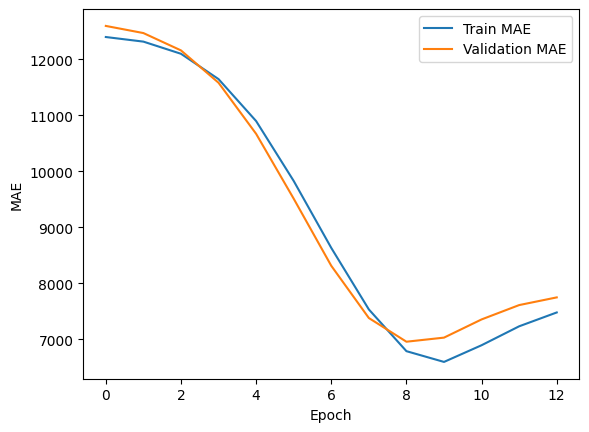

In [25]:
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')

plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()
plt.show()

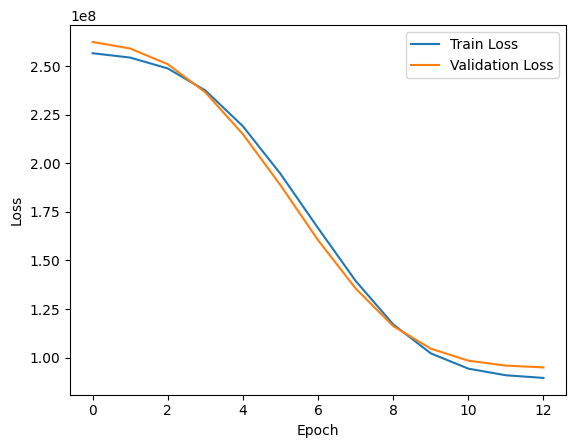

In [26]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()